# Predicting Student Admissions with Neural Networks
In this notebook, we predict student admissions to graduate school at UCLA based on three pieces of data:
- GRE Scores (Test)
- GPA Scores (Grades)
- Class rank (1-4)

The dataset originally came from here: http://www.ats.ucla.edu/

## Loading the data
To load the data and format it nicely, we will use two very useful packages called Pandas and Numpy. You can read on the documentation here:
- https://pandas.pydata.org/pandas-docs/stable/
- https://docs.scipy.org/

In [2]:
# Importing pandas and numpy
import pandas as pd
import numpy as np

# Reading the csv file into a pandas DataFrame
data = pd.read_csv('student_data.csv')

# Printing out the first 10 rows of our data
#data.head(10)
data[:10]
#data.head(10)

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4
5,1,760,3.00,2
6,1,560,2.98,1
7,0,400,3.08,2
8,1,540,3.39,3
9,0,700,3.92,2


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB


In [4]:
data.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.00000
mean,0.317500,587.700000,3.389900,2.48500
std,0.466087,115.516536,0.380567,0.94446
min,0.000000,220.000000,2.260000,1.00000
25%,0.000000,520.000000,3.130000,2.00000
50%,0.000000,580.000000,3.395000,2.00000
75%,1.000000,660.000000,3.670000,3.00000
max,1.000000,800.000000,4.000000,4.00000


In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data=scaler.fit_transform(data[['gre','gpa','rank']])

In [10]:
print(scaled_data)

[[0.27586207 0.77586207 0.66666667]
 [0.75862069 0.81034483 0.66666667]
 [1.         1.         0.        ]
 ...
 [0.4137931  0.21264368 0.33333333]
 [0.82758621 0.79885057 0.33333333]
 [0.65517241 0.93678161 0.66666667]]


In [11]:
scaled_df=pd.DataFrame(scaled_data,columns=['gre','gpa','rank'])

In [12]:
scaled_df.describe()

,gre,gpa,rank
count,400.000000,400.000000,400.000000
mean,0.633966,0.649368,0.495000
std,0.199166,0.218717,0.314820
min,0.000000,0.000000,0.000000
25%,0.517241,0.500000,0.333333
50%,0.620690,0.652299,0.333333
75%,0.758621,0.810345,0.666667
max,1.000000,1.000000,1.000000


In [13]:
scaled_df['admit']=data['admit']

In [14]:
scaled_df.describe()

,gre,gpa,rank,admit
count,400.000000,400.000000,400.000000,400.000000
mean,0.633966,0.649368,0.495000,0.317500
std,0.199166,0.218717,0.314820,0.466087
min,0.000000,0.000000,0.000000,0.000000
25%,0.517241,0.500000,0.333333,0.000000
50%,0.620690,0.652299,0.333333,0.000000
75%,0.758621,0.810345,0.666667,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [15]:
scaled_df.corr()

,gre,gpa,rank,admit
gre,1.000000,0.384266,-0.123447,0.184434
gpa,0.384266,1.000000,-0.057461,0.178212
rank,-0.123447,-0.057461,1.000000,-0.242513
admit,0.184434,0.178212,-0.242513,1.000000


## Plotting the data

First let's make a plot of our data to see how it looks. In order to have a 2D plot, let's ingore the rank.

In [16]:
import seaborn as sns

<Axes: xlabel='gre', ylabel='gpa'>

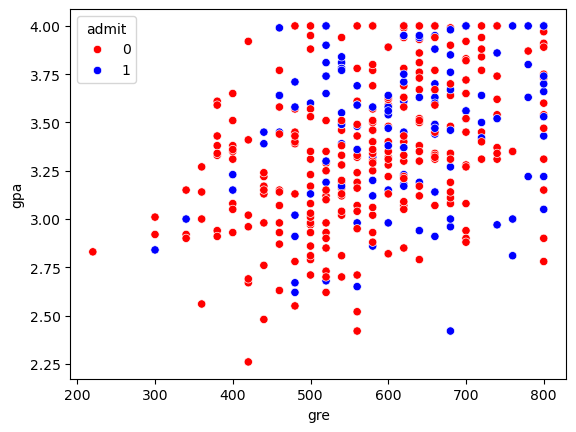

In [20]:
sns.scatterplot(data=data,x='gre',y='gpa',hue='admit',palette=['red','blue'])

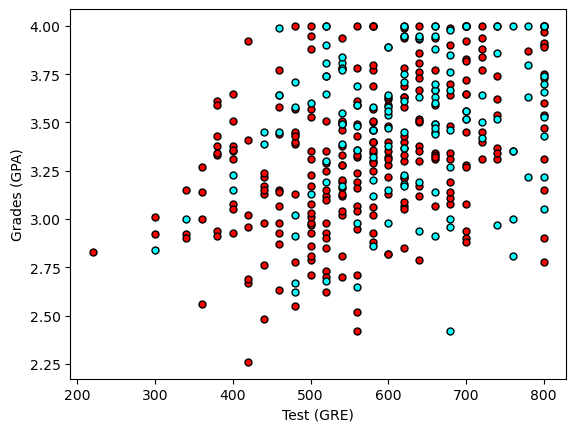

In [21]:
# Importing matplotlib
import matplotlib.pyplot as plt

# Function to help us plot
def plot_points(data):
    X = np.array(data[["gre","gpa"]])# predictor
    y = np.array(data["admit"])#labels
    admitted = X[np.argwhere(y==1)] # x[indexes of where admit =1]
    rejected = X[np.argwhere(y==0)] #
    plt.scatter([s[0][0] for s in rejected], [s[0][1] for s in rejected], s = 25, color = 'red', edgecolor = 'k')
    plt.scatter([s[0][0] for s in admitted], [s[0][1] for s in admitted], s = 25, color = 'cyan', edgecolor = 'k')
    plt.xlabel('Test (GRE)')
    plt.ylabel('Grades (GPA)')
    
# Plotting the points
plot_points(data)
plt.show()

Roughly, it looks like the students with high scores in the grades and test passed, while the ones with low scores didn't, but the data is not as nicely separable as we hoped it would. Maybe it would help to take the rank into account? Let's make 4 plots, each one for each rank.

In [22]:
data['rank'].value_counts()

rank
2    151
3    121
4     67
1     61
Name: count, dtype: int64

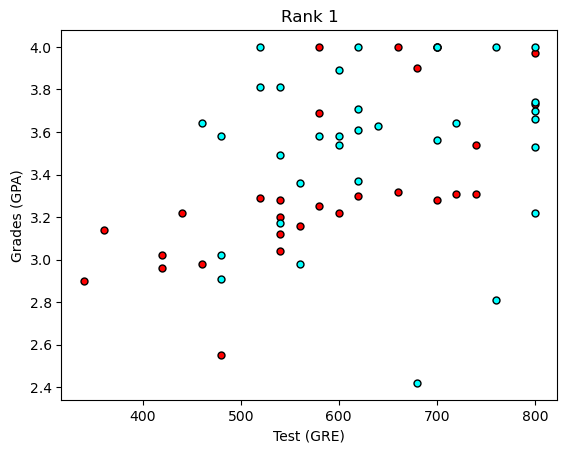

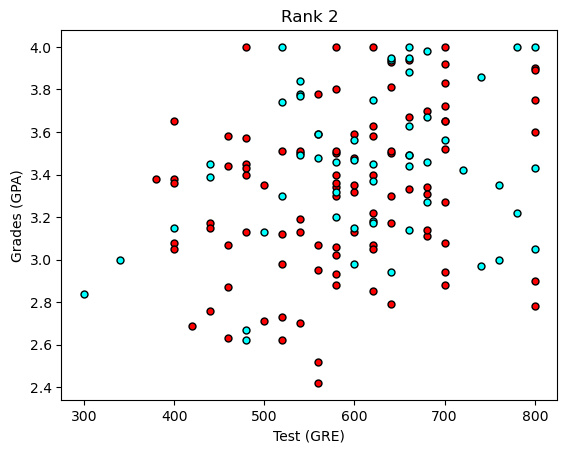

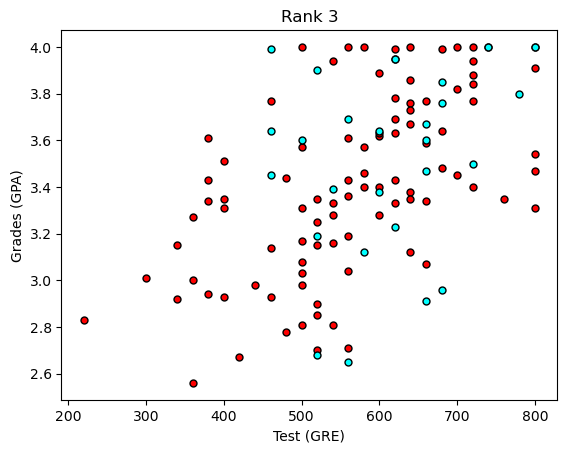

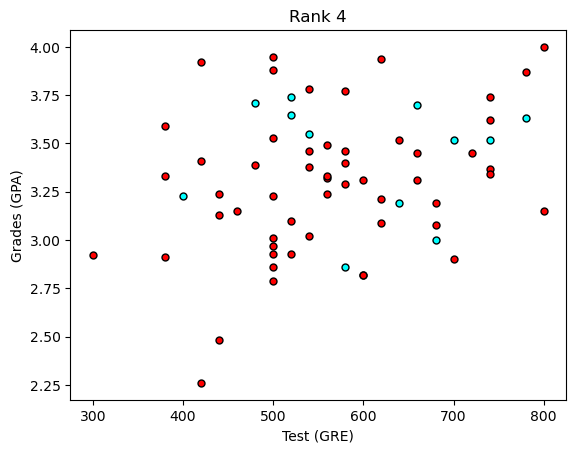

In [23]:
# Separating the ranks
data_rank1 = data[data["rank"]==1]
data_rank2 = data[data["rank"]==2]
data_rank3 = data[data["rank"]==3]
data_rank4 = data[data["rank"]==4]

# Plotting the graphs
plot_points(data_rank1)
plt.title("Rank 1")
plt.show()
plot_points(data_rank2)
plt.title("Rank 2")
plt.show()
plot_points(data_rank3)
plt.title("Rank 3")
plt.show()
#plt.subplot(2,2,4)
plot_points(data_rank4)
plt.title("Rank 4")
plt.show()

In [24]:
data.corr()

,admit,gre,gpa,rank
admit,1.000000,0.184434,0.178212,-0.242513
gre,0.184434,1.000000,0.384266,-0.123447
gpa,0.178212,0.384266,1.000000,-0.057461
rank,-0.242513,-0.123447,-0.057461,1.000000


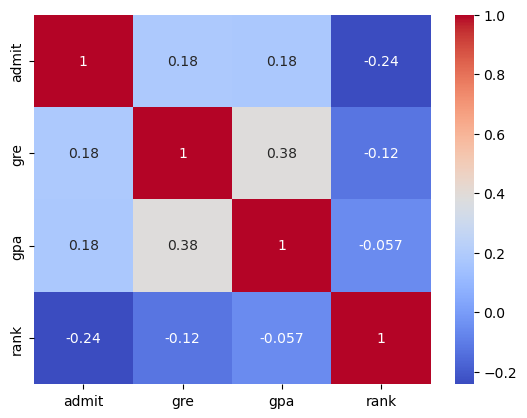

In [25]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

This looks more promising, as it seems that the lower the rank, the higher the acceptance rate. Let's use the rank as one of our inputs. In order to do this, we should one-hot encode it.

## TODO: One-hot encoding the rank
Use the `get_dummies` function in numpy in order to one-hot encode the data.

In [26]:
data

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4
...,...,...,...,...
395,0,620,4.00,2
396,0,560,3.04,3
397,0,460,2.63,2
398,0,700,3.65,2


In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
ohe=OneHotEncoder(sparse_output=False)

In [31]:
rank_encoded=ohe.fit_transform(data[['rank']])

In [32]:
rank_encoded

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

In [33]:
# TODO:  Make dummy variables for rank
one_hot_data = pd.get_dummies(data,columns=['rank'])
one_hot_data.head()

# TODO: Drop the previous rank column
drop_rank = one_hot_data.drop(columns=['rank_1','rank_2','rank_3','rank_4'])
drop_rank.head()
#one_hot_data = pass

# Print the first 10 rows of our data
print(one_hot_data[:10])
#one_hot_data[:10]


   admit  gre   gpa  rank_1  rank_2  rank_3  rank_4
0      0  380  3.61   False   False    True   False
1      1  660  3.67   False   False    True   False
2      1  800  4.00    True   False   False   False
3      1  640  3.19   False   False   False    True
4      0  520  2.93   False   False   False    True
5      1  760  3.00   False    True   False   False
6      1  560  2.98    True   False   False   False
7      0  400  3.08   False    True   False   False
8      1  540  3.39   False   False    True   False
9      0  700  3.92   False    True   False   False


In [34]:
one_hot_data

,admit,gre,gpa,rank_1,rank_2,rank_3,rank_4
0,0,380,3.61,False,False,True,False
1,1,660,3.67,False,False,True,False
2,1,800,4.00,True,False,False,False
3,1,640,3.19,False,False,False,True
4,0,520,2.93,False,False,False,True
...,...,...,...,...,...,...,...
395,0,620,4.00,False,True,False,False
396,0,560,3.04,False,False,True,False
397,0,460,2.63,False,True,False,False
398,0,700,3.65,False,True,False,False


## TODO: Scaling the data
The next step is to scale the data. We notice that the range for grades is 1.0-4.0, whereas the range for test scores is roughly 200-800, which is much larger. This means our data is skewed, and that makes it hard for a neural network to handle. Let's fit our two features into a range of 0-1, by dividing the grades by 4.0, and the test score by 800.

In [35]:
# min max scaler
processed_data = MinMaxScaler().fit_transform(drop_rank)
processed_data = pd.DataFrame(processed_data, columns=drop_rank.columns)
processed_data.head()

,admit,gre,gpa
0,0.0,0.275862,0.775862
1,1.0,0.758621,0.810345
2,1.0,1.000000,1.000000
3,1.0,0.724138,0.534483
4,0.0,0.517241,0.385057


In [42]:
# Making a copy of our data
processed_data = one_hot_data[:]
processed_data['gre']=(processed_data['gre']-processed_data['gre'].min())/(processed_data['gre'].max()-processed_data['gre'].min())
                                
# TODO: Scale the columns
processed_data['gpa']=(processed_data['gpa']-processed_data['gpa'].min())/(processed_data['gpa'].max()-processed_data['gpa'].min())
# processed_data['rank']=(processed_data['rank']-processed_data['rank'].min())/(processed_data['rank'].max()-processed_data['rank'].min())

# Printing the first 10 rows of our procesed data
processed_data[:10]

,admit,gre,gpa,rank_1,rank_2,rank_3,rank_4
0,0,0.275862,0.775862,False,False,True,False
1,1,0.758621,0.810345,False,False,True,False
2,1,1.000000,1.000000,True,False,False,False
3,1,0.724138,0.534483,False,False,False,True
4,0,0.517241,0.385057,False,False,False,True
5,1,0.931034,0.425287,False,True,False,False
6,1,0.586207,0.413793,True,False,False,False
7,0,0.310345,0.471264,False,True,False,False
8,1,0.551724,0.649425,False,False,True,False
9,0,0.827586,0.954023,False,True,False,False


## Splitting the data into Training and Testing

In order to test our algorithm, we'll split the data into a Training and a Testing set. The size of the testing set will be 10% of the total data.

In [43]:
sample = np.random.choice(processed_data.index, size=int(len(processed_data)*0.9), replace=False)
train_data, test_data = processed_data.iloc[sample], processed_data.drop(sample)

print("Number of training samples is", len(train_data))
print("Number of testing samples is", len(test_data))
print(train_data[:10])
print(test_data[:10])

Number of training samples is 360
Number of testing samples is 40
     admit       gre       gpa  rank_1  rank_2  rank_3  rank_4
391      1  0.758621  0.931034   False    True   False   False
142      0  0.689655  0.965517   False   False   False    True
22       0  0.655172  0.321839   False   False   False    True
218      0  0.413793  0.413793    True   False   False   False
92       0  1.000000  0.942529   False    True   False   False
83       0  0.275862  0.373563   False   False   False    True
185      0  1.000000  0.770115   False    True   False   False
222      1  0.448276  0.436782    True   False   False   False
212      0  0.413793  0.350575   False    True   False   False
256      1  0.517241  0.597701   False    True   False   False
     admit       gre       gpa  rank_1  rank_2  rank_3  rank_4
6        1  0.586207  0.413793    True   False   False   False
10       0  1.000000  1.000000   False   False   False    True
11       0  0.379310  0.551724    True   False   Fal

## Splitting the data into features and targets (labels)
Now, as a final step before the training, we'll split the data into features (X) and targets (y).

In [44]:
features = train_data.drop('admit', axis=1)
targets = train_data['admit']
features_test = test_data.drop('admit', axis=1)
targets_test = test_data['admit']

print(features[:10])
print(targets[:10])

          gre       gpa  rank_1  rank_2  rank_3  rank_4
391  0.758621  0.931034   False    True   False   False
142  0.689655  0.965517   False   False   False    True
22   0.655172  0.321839   False   False   False    True
218  0.413793  0.413793    True   False   False   False
92   1.000000  0.942529   False    True   False   False
83   0.275862  0.373563   False   False   False    True
185  1.000000  0.770115   False    True   False   False
222  0.448276  0.436782    True   False   False   False
212  0.413793  0.350575   False    True   False   False
256  0.517241  0.597701   False    True   False   False
391    1
142    0
22     0
218    0
92     0
83     0
185    0
222    1
212    0
256    1
Name: admit, dtype: int64


## Training the 2-layer Neural Network
The following function trains the 2-layer neural network. First, we'll write some helper functions.

In [46]:
# Activation (sigmoid) function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid function
def sigmoid_prime(x):
    sig = sigmoid(x)
    return sig * (1 - sig)

# Error formula (Mean Squared Error)
def error_formula(y, output):
    return 0.5 * (y - output) ** 2

# TODO: Backpropagate the error
Now it's your turn to shine. Write the error term. Remember that this is given by the equation $$ -(y-\hat{y}) \sigma'(x) $$

In [47]:
# TODO: Write the error term formula
def error_term_formula(y, output):
    pass

In [ ]:
# Neural Network hyperparameters
epochs = 1000
learnrate = 0.5

# Training function
def train_nn(features, targets, epochs, learnrate):
    
    # Use to same seed to make debugging easier
    np.random.seed(42)

    n_records, n_features = features.shape
    last_loss = None

    # Initialize weights
    weights = np.random.normal(scale=1 / n_features**0.5, size=n_features)

    for e in range(epochs):
        del_w = np.zeros(weights.shape)
        for x, y in zip(features.values, targets):
            # Loop through all records, x is the input, y is the target

            # Activation of the output unit
            #   Notice we multiply the inputs and the weights here 
            #   rather than storing h as a separate variable 
            output = sigmoid(np.dot(x, weights))

            # The error, the target minus the network output
            error = y - output

            # The error term
            #   Notice we calulate f'(h) here instead of defining a separate
            #   sigmoid_prime function. This just makes it faster because we
            #   can re-use the result of the sigmoid function stored in
            #   the output variable
            error_term = error * sigmoid_prime(np.dot(x, weights))

            # The gradient descent step, the error times the gradient times the inputs
            del_w += error_term * x

        # Update the weights here. The learning rate times the 
        # change in weights, divided by the number of records to average
        weights += learnrate * del_w / n_records

        # Printing out the mean square error on the training set
        if e % (epochs / 10) == 0:
            out = sigmoid(np.dot(features, weights))
            loss = np.mean((out - targets) ** 2)
            print("Epoch:", e)
            if last_loss and last_loss < loss:
                print("Train loss: ", loss, "  WARNING - Loss Increasing")
            else:
                print("Train loss: ", loss)
            last_loss = loss
            print("=========")
    print("Finished training!")
    return weights
    
weights = train_nn(features, targets, epochs, learnrate)

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('O') to dtype('float64') with casting rule 'same_kind'

## Calculating the Accuracy on the Test Data

In [ ]:
# Calculate accuracy on test data
tes_out = sigmoid(np.dot(features_test, weights))
predictions = tes_out > 0.5
accuracy = np.mean(predictions == targets_test)
print("Prediction accuracy: {:.3f}".format(accuracy))